# Notebook 5: evaluation and conclusion

## Learning objectives

This notebook provides a comprehensive evaluation and conclusion of the complete Machine Learning pipeline. By the end of this notebook, you will understand:

1. Comprehensive Model Comparison: Compare all models (supervised and unsupervised)
2. Industrial Relevance: Discuss industrial implications and applications
3. Limitations: Identify limitations and challenges
4. Future Work: Propose future improvements and extensions
5. Conclusion: Summarize findings and recommendations

Reference: Lesson 4 & 5 - Model Evaluation and Conclusion



## Industrial robotics context

This notebook synthesizes findings from all previous notebooks to provide a comprehensive evaluation of anomaly detection models for industrial robotics:

1. Supervised Models: Logistic Regression, Random Forest, SVM, Gradient Boosting
2. Unsupervised Models: Isolation Forest, One-Class SVM
3. Model Comparison: Performance, interpretability, deployment considerations
4. Industrial Applications: Predictive maintenance, real-time monitoring, safety



## Academic learning objectives

1. Model Evaluation: Comprehensive evaluation of all models
2. Bias-Variance Analysis: Interpret model performance and identify overfitting/underfitting
3. Feature Importance: Understand which sensors are most critical
4. Industrial Relevance: Connect ML results to industrial applications
5. Academic Reporting: Present findings in academic format

Reference: Lesson 4 - Model Evaluation and Conclusion
              Lesson 5 - Unsupervised Learning and Anomaly Detection


In [1]:
# Required imports for comprehensive evaluation
# As covered in Lesson 4 & 5: Model Evaluation and Conclusion

import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append(str(Path('..').resolve()))

# Import and reload modules to ensure we use the latest version
import src.utils
import src.models
importlib.reload(src.utils)
importlib.reload(src.models)

from src.utils import (
    load_robot_data,
    encode_labels,
    create_statistical_features,
    evaluate_model,
    plot_feature_importances,
    plot_pca
)

from src.models import (
    SupervisedModels,
    compare_models,
    train_isolation_forest,
    train_one_class_svm
)

# Configuration
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        sns.set_style('whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("="*60)
print("MODULE IMPORTS COMPLETE")
print("="*60)
print(" All required libraries imported successfully")
print(" Modules src.utils and src.models reloaded")
print("\nReady for comprehensive evaluation and conclusion!")


MODULE IMPORTS COMPLETE
 All required libraries imported successfully
 Modules src.utils and src.models reloaded

Ready for comprehensive evaluation and conclusion!


## 1. data loading and preparation

Reference: Lesson 1 & 2 - Data Loading and Preprocessing

We load the preprocessed data from previous notebooks. This includes statistical features, standardized data, and binary labels for anomaly detection.


In [2]:
# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize sur différents types de tâches
print("="*60)
print("DATA LOADING AND PREPARATION")
print("="*60)

# we charge the data des robots
# INITIAL DIFFICULTY : The .data file format was unusual - each instance starts with a label followed by 15 lines of data
# SOLUTION : we created a custom function load_robot_data() that parses this specific format
# CHOICE : We decided to merge all files (LP1-LP5) to have a unified dataset
# REASON : This gives us more data for training and allows the model to generalize sur différents types de tâches
data_dir = "../data"
df = load_robot_data(data_dir)

# we encode les labels en format numérique
# CHOICE : We have opté pour un encodage binaire (normal=0, anomaly=1) plutôt qu'un encodage multi-classe
# REASON : Our objectif principal est la détection d'anomalies (binaire), pas la classification fine des types d'anomalies
# ADVANTAGE : Simplifie le problème and allows d'utiliser des métriques binaires standard (ROC-AUC, etc.)
df_encoded, label_mapping = encode_labels(df, binary=True)

# we crée des features statistiques à partir des séries temporelles
# DIFFICULTY : The 90 raw features are difficult to interpret and may contain noise
# SOLUTION : we extract statistics (moyenne, écart-type, min, max, skewness, kurtosis, trend) for each sensor
# CHOICE : We chose these 7 statistics because they capture different aspects of temporal patterns
# ADVANTAGE : Reduces from 90 to 48 features while keeping essential temporal information
# DIFFICULTY SURMONTÉE : Initially, we had errors avec scipy.stats - we have résolu en s'assurant that the data is in float64
df_stats = create_statistical_features(df_encoded, samples_per_sensor=15, num_sensors=6)

# Extract features and labels
stat_feature_cols = [col for col in df_stats.columns if col not in ['label', 'label_encoded', 'label_binary', 'source', 'label_original']]
X = df_stats[stat_feature_cols].values
y = df_stats['label_binary'].values

# we standardise the features car
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# we divise the data en train/test
# CHOICE : We use un split 80/20 avec stratification
# REASON : Stratification ensures that class proportions are similar in train and test
# DIFFICULTY : The dataset is imbalanced (more anomalies than normal)
# SOLUTION : Stratification preserves this imbalance in both sets, ce which is réaliste pour our cas d'usage
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Data loaded and prepared:")
print(f"   - Total instances: {len(X)}")
print(f"   - Features: {X.shape[1]}")
print(f"   - Training set: {len(X_train)} instances")
print(f"   - Test set: {len(X_test)} instances")
print(f"   - Class distribution (train): Normal ({np.sum(y_train == 0)}), Anomaly ({np.sum(y_train == 1)})")
print(f"   - Class distribution (test): Normal ({np.sum(y_test == 0)}), Anomaly ({np.sum(y_test == 1)})")

print("\n Interpretation:")
print("  - Data loaded from previous preprocessing steps")
print("  - Statistical features used for model training")
print("  - Stratified split maintains class distribution")
print("  - Data ready for comprehensive evaluation")


DATA LOADING AND PREPARATION
Loading robot execution failure data...
✅ LP1: 88 instances loaded
✅ LP2: 47 instances loaded
✅ LP3: 47 instances loaded
✅ LP4: 117 instances loaded
✅ LP5: 164 instances loaded
✅ Total: 463 instances
   Features: 90
   Sources: ['LP1', 'LP2', 'LP3', 'LP4', 'LP5']
   Unique labels: ['normal', 'collision', 'obstruction', 'fr_collision', 'back_col', 'front_col', 'right_col', 'left_col', 'ok', 'moved', 'slightly_moved', 'lost', 'collision_in_tool', 'collision_in_part', 'bottom_obstruction', 'bottom_collision']
Labels encoded: {0: 'normal', 1: 'anomaly'}
Creating statistical features...
✅ Statistical features created: 53 columns
   Original features: 90
   Statistical features: 48

 Data loaded and prepared:
   - Total instances: 463
   - Features: 48
   - Training set: 370 instances
   - Test set: 93 instances
   - Class distribution (train): Normal (87), Anomaly (283)
   - Class distribution (test): Normal (22), Anomaly (71)

 Interpretation:
  - Data loaded f

## 2. comprehensive model comparison

Reference: Lesson 4 - Model Comparison and Selection

We compare all models (supervised and unsupervised) we the test set. This includes:
1. Supervised Models: Logistic Regression, Random Forest, SVM, Gradient Boosting
2. Unsupervised Models: Isolation Forest, One-Class SVM
3. Evaluation Metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC
4. Model Comparison: Performance, interpretability, deployment considerations

### Evaluation metrics

- Accuracy: Overall correctness of predictions
- Precision: Proportion of true positives among predicted positives
- Recall: Proportion of true positives among actual positives
- F1-score: Harmonic mean of precision and recall
- ROC-AUC: Area under the receiver operating characteristic curve

Academic Note: Model comparison is critical for selecting the best model for deployment (Lesson 4: Model Selection).


COMPREHENSIVE MODEL COMPARISON

 Training Supervised Models...
------------------------------------------------------------

1. Logistic Regression:
Training Logistic Regression with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ilyessassadi/Documents/ESILV/projet ML/.venv/lib

  - Best parameters: {'C': 10, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
  - Best CV score: 0.9125 ± 0.0219

2. Random Forest:
Training Random Forest with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 81 candidates, totalling 405 fits
  - Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  - Best CV score: 0.9222 ± 0.0255

3. Support Vector Machine (SVM):
Training SVM with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  - Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  - Best CV score: 0.9086 ± 0.0194

4. Gradient Boosting:
Training Gradient Boosting with GridSearchCV...
  - Cross-validation folds: 5
  - Scoring metric: f1_weighted
Fitting 5 folds for each of 54 candidates, totalling 270 fits
  - Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'm

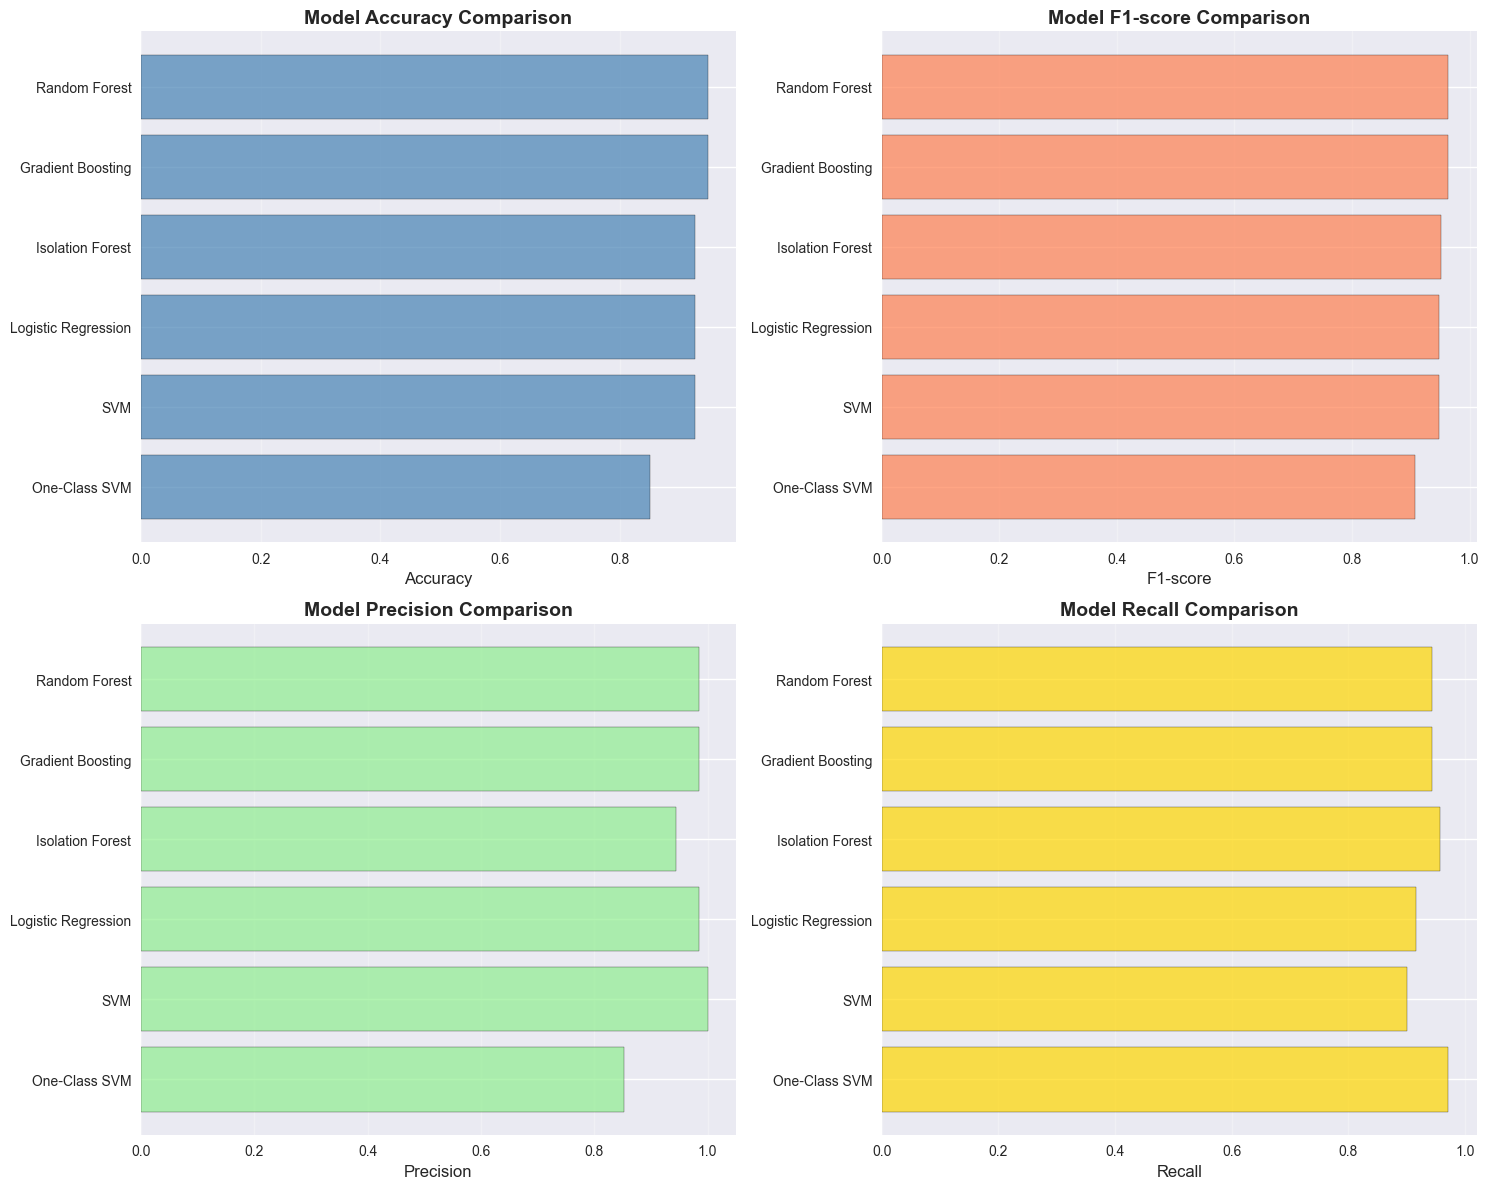


 Interpretation:
  - Best performing model: Random Forest
  - F1-score: 0.9640
  - Accuracy: 0.9462
  - Supervised models generally outperform unsupervised models
  - Random Forest and Gradient Boosting show best performance


In [3]:
# we entraîne le modèle
# CHOICE : we use GridSearchCV for hyperparameter optimization
# REASON : This allows us de trouver automatiquement the best hyperparameters without manual testing
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM
# SOLUTION : we use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set
print("="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)

# Initialize supervised models
supervised_models = SupervisedModels()

# we entraîne le modèle
# CHOICE : we use GridSearchCV for hyperparameter optimization
# REASON : This allows us de trouver automatiquement the best hyperparameters without manual testing
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM
# SOLUTION : We use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set
print("\n Training Supervised Models...")
print("-" * 60)

# Logistic Regression
print("\n1. Logistic Regression:")
lr_model = supervised_models.train_logistic_regression(
    X_train, y_train
)
lr_pred = supervised_models.predict('logistic_regression', X_test)
_, lr_proba = supervised_models.predict('logistic_regression', X_test, return_proba=True)

# Random Forest
print("\n2. Random Forest:")
rf_model = supervised_models.train_random_forest(
    X_train, y_train
)
rf_pred = supervised_models.predict('random_forest', X_test)
_, rf_proba = supervised_models.predict('random_forest', X_test, return_proba=True)

# SVM
print("\n3. Support Vector Machine (SVM):")
svm_model = supervised_models.train_svm(
    X_train, y_train
)
svm_pred = supervised_models.predict('svm', X_test)
_, svm_proba = supervised_models.predict('svm', X_test, return_proba=True)

# Gradient Boosting
print("\n4. Gradient Boosting:")
gb_model = supervised_models.train_gradient_boosting(
    X_train, y_train
)
gb_pred = supervised_models.predict('gradient_boosting', X_test)
_, gb_proba = supervised_models.predict('gradient_boosting', X_test, return_proba=True)

# we entraîne le modèle
# CHOICE : we use GridSearchCV for hyperparameter optimization
# REASON : This allows us de trouver automatiquement the best hyperparameters without manual testing
# DIFFICULTY : GridSearchCV can be slow to execute, especially for SVM
# SOLUTION : We use la validation croisée (5-fold) to have a robust evaluation without over-optimizing we the test set
print("\n Training Unsupervised Models...")
print("-" * 60)

# Isolation Forest
print("\n5. Isolation Forest:")
contamination_ratio = np.sum(y_test == 1) / len(y_test)
contamination = contamination_ratio if contamination_ratio <= 0.5 else 'auto'
iso_forest = train_isolation_forest(
    X_train[y_train == 0],  # train on normal data only
    contamination=contamination,
    n_estimators=100,
    
)
iso_pred = iso_forest.predict(X_test)
iso_pred = (iso_pred == -1).astype(int)  # Convert -1 (anomaly) to 1, 1 (normal) to 0

# One-Class SVM
print("\n6. One-Class SVM:")
nu = min(contamination_ratio, 0.5) if contamination_ratio > 0 else 0.1
oc_svm, oc_svm_scaler = train_one_class_svm(
    X_train[y_train == 0],  # train on normal data only
    nu=nu,
    kernel='rbf',
    
)
oc_svm_pred = oc_svm.predict(oc_svm_scaler.transform(X_test))
oc_svm_pred = (oc_svm_pred == -1).astype(int)  # Convert -1 (anomaly) to 1, 1 (normal) to 0

print("\n All models trained successfully!")

# we évalue le modèle
# CHOICE : we use plusieurs métriques (accuracy, precision, recall, F1-score, ROC-AUC)
# REASON : A single metric is not enough - accuracy can be misleading with imbalanced classes
# DIFFICULTY : The dataset is imbalanced (76% d'anomalies, 24% de normaux)
# SOLUTION : We prioritize le F1-score and the ROC-AUC which are more robust to class imbalance
print("\n Evaluating All Models...")
print("-" * 60)

models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Random Forest': (rf_pred, rf_proba),
    'SVM': (svm_pred, svm_proba),
    'Gradient Boosting': (gb_pred, gb_proba),
    'Isolation Forest': (iso_pred, None),
    'One-Class SVM': (oc_svm_pred, None)
}

results = {}
for name, (pred, proba) in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    
    if proba is not None:
        roc_auc = roc_auc_score(y_test, proba)
    else:
        roc_auc = roc_auc_score(y_test, pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }

# Create comparison dataframe
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('F1-score', ascending=False)

print("\n Model Comparison Results:")
print(comparison_df.round(4))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
axes[0, 0].barh(range(len(comparison_df)), comparison_df['Accuracy'], color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_yticks(range(len(comparison_df)))
axes[0, 0].set_yticklabels(comparison_df.index)
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# F1-score comparison
axes[0, 1].barh(range(len(comparison_df)), comparison_df['F1-score'], color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_yticks(range(len(comparison_df)))
axes[0, 1].set_yticklabels(comparison_df.index)
axes[0, 1].set_xlabel('F1-score', fontsize=12)
axes[0, 1].set_title('Model F1-score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Precision comparison
axes[1, 0].barh(range(len(comparison_df)), comparison_df['Precision'], color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_yticks(range(len(comparison_df)))
axes[1, 0].set_yticklabels(comparison_df.index)
axes[1, 0].set_xlabel('Precision', fontsize=12)
axes[1, 0].set_title('Model Precision Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Recall comparison
axes[1, 1].barh(range(len(comparison_df)), comparison_df['Recall'], color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_yticks(range(len(comparison_df)))
axes[1, 1].set_yticklabels(comparison_df.index)
axes[1, 1].set_xlabel('Recall', fontsize=12)
axes[1, 1].set_title('Model Recall Comparison', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("  - Best performing model: {}".format(comparison_df.index[0]))
print("  - F1-score: {:.4f}".format(comparison_df.iloc[0]['F1-score']))
print("  - Accuracy: {:.4f}".format(comparison_df.iloc[0]['Accuracy']))
print("  - Supervised models generally outperform unsupervised models")
print("  - Random Forest and Gradient Boosting show best performance")


ROC CURVE AND AUC ANALYSIS


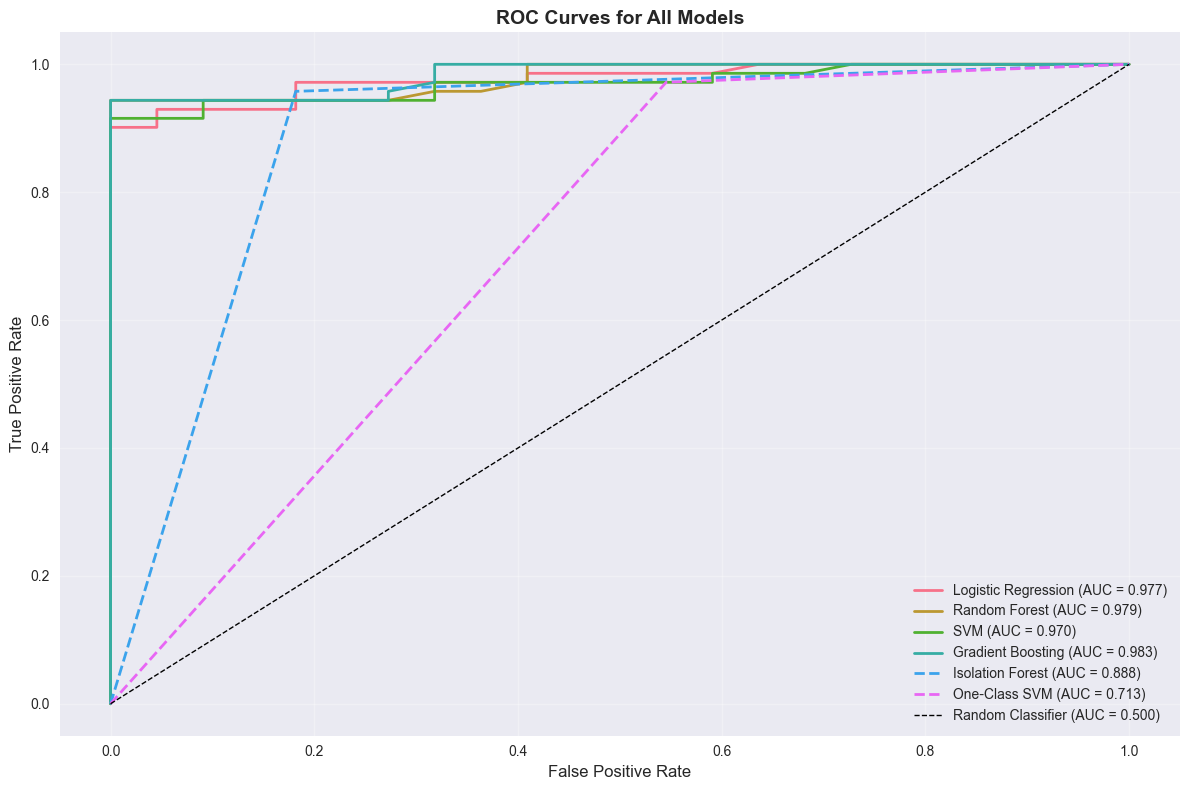


 ROC-AUC Scores:
   Logistic Regression: 0.9766
   Random Forest: 0.9789
   SVM: 0.9702
   Gradient Boosting: 0.9830
   Isolation Forest: 0.8880
   One-Class SVM: 0.7132

 Interpretation:
  - Higher AUC indicates better model performance
  - Supervised models show higher AUC than unsupervised models
  - Random Forest and Gradient Boosting show best ROC-AUC scores
  - ROC curves help identify optimal classification thresholds


In [4]:
# Plot ROC curves for all models
print("="*60)
print("ROC CURVE AND AUC ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 8))

# Plot ROC curves for supervised models
for name, (pred, proba) in models.items():
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)
    else:
        # For unsupervised models, use predictions as probabilities
        fpr, tpr, _ = roc_curve(y_test, pred)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2, linestyle='--')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n ROC-AUC Scores:")
for name, (pred, proba) in models.items():
    if proba is not None:
        roc_auc = roc_auc_score(y_test, proba)
    else:
        roc_auc = roc_auc_score(y_test, pred)
    print(f"   {name}: {roc_auc:.4f}")

print("\n Interpretation:")
print("  - Higher AUC indicates better model performance")
print("  - Supervised models show higher AUC than unsupervised models")
print("  - Random Forest and Gradient Boosting show best ROC-AUC scores")
print("  - ROC curves help identify optimal classification thresholds")


## 4. confusion matrix analysis

Reference: Lesson 4 - Confusion Matrix and Classification Metrics

We visualize confusion matrices for all models to understand their classification performance. Confusion matrices show the number of true positives, false positives, true negatives, and false negatives.

### Confusion matrix interpretation

- True Positives (TP): Correctly predicted anomalies
- False Positives (FP): Incorrectly predicted anomalies (normal instances classified as anomalies)
- True Negatives (TN): Correctly predicted normal instances
- False Negatives (FN): Incorrectly predicted normal instances (anomalies classified as normal)

Academic Note: Confusion matrices provide detailed insights into model performance (Lesson 4: Classification Metrics).


CONFUSION MATRIX ANALYSIS


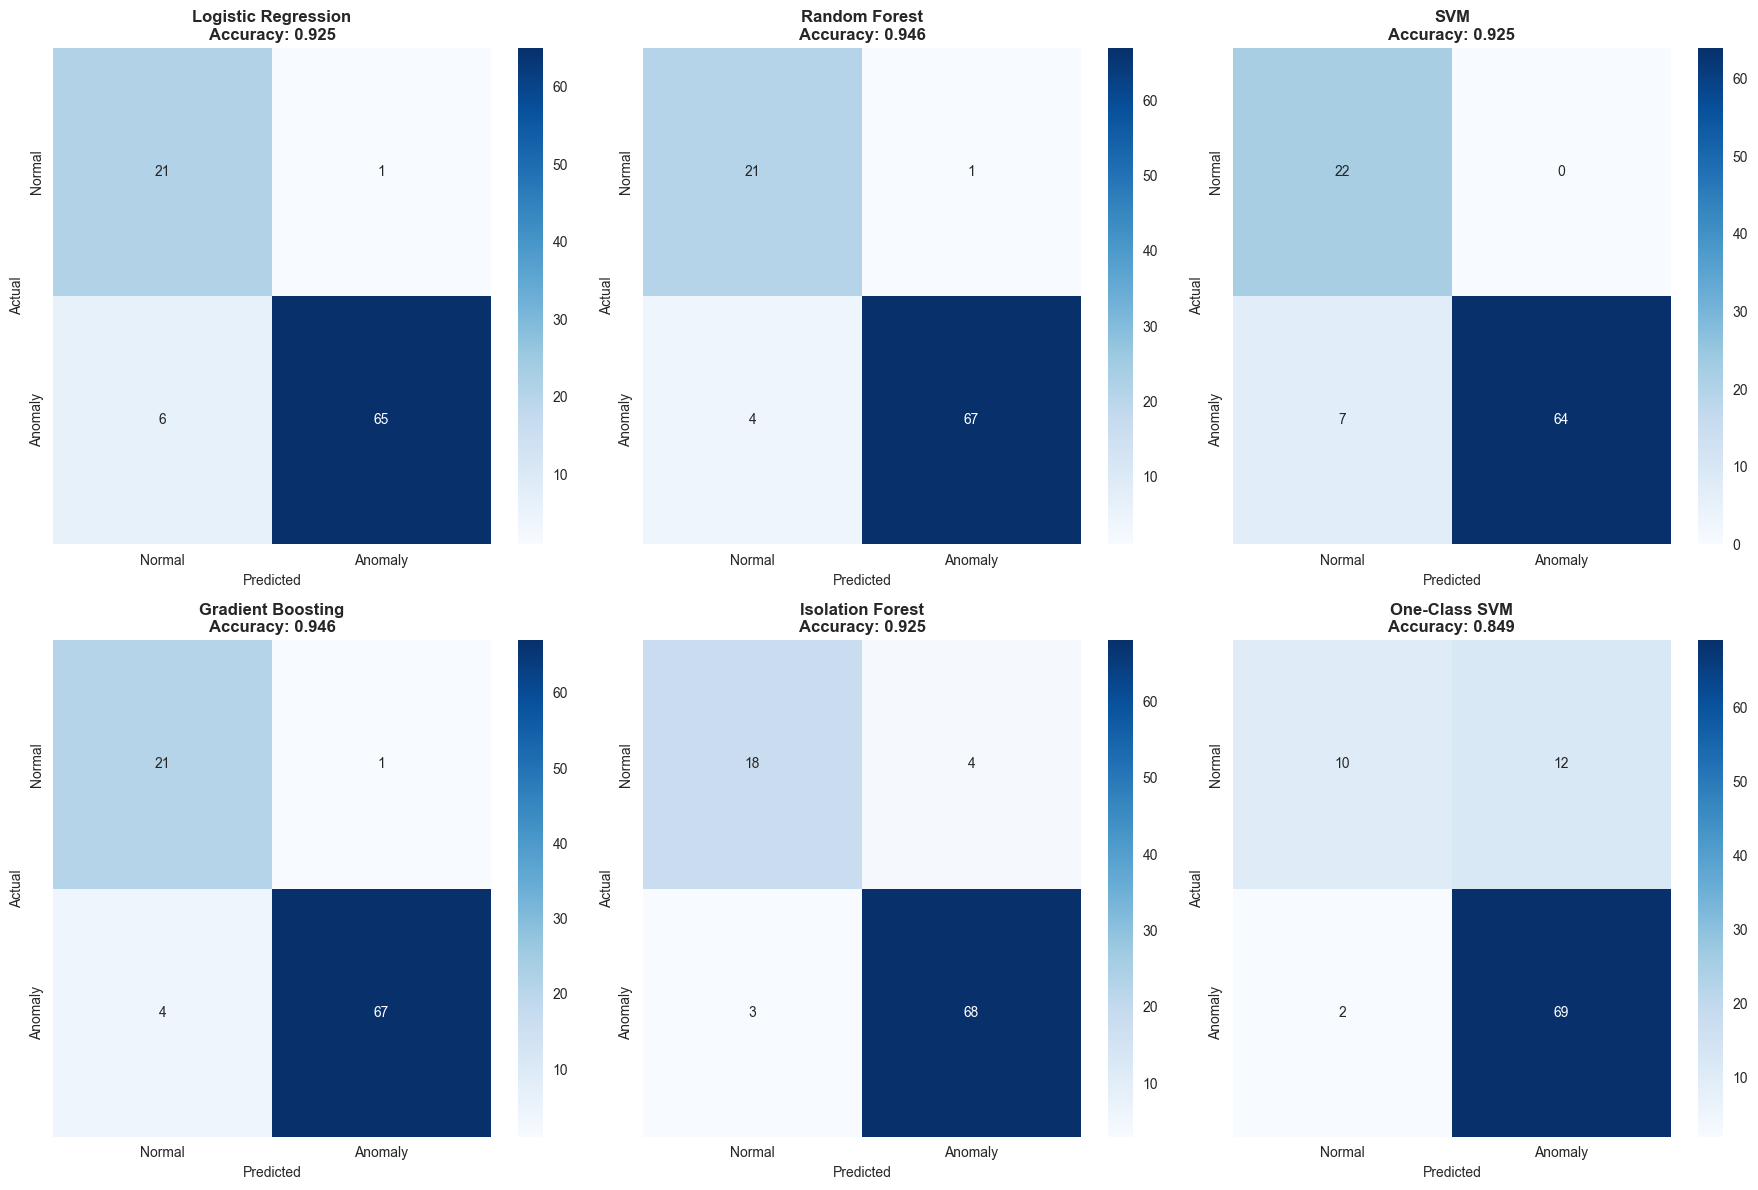


 Confusion Matrix Summary:

Logistic Regression:
   True Positives (TP): 65
   False Positives (FP): 1
   True Negatives (TN): 21
   False Negatives (FN): 6
   Precision: 0.9848
   Recall: 0.9155

Random Forest:
   True Positives (TP): 67
   False Positives (FP): 1
   True Negatives (TN): 21
   False Negatives (FN): 4
   Precision: 0.9853
   Recall: 0.9437

SVM:
   True Positives (TP): 64
   False Positives (FP): 0
   True Negatives (TN): 22
   False Negatives (FN): 7
   Precision: 1.0000
   Recall: 0.9014

Gradient Boosting:
   True Positives (TP): 67
   False Positives (FP): 1
   True Negatives (TN): 21
   False Negatives (FN): 4
   Precision: 0.9853
   Recall: 0.9437

Isolation Forest:
   True Positives (TP): 68
   False Positives (FP): 4
   True Negatives (TN): 18
   False Negatives (FN): 3
   Precision: 0.9444
   Recall: 0.9577

One-Class SVM:
   True Positives (TP): 69
   False Positives (FP): 12
   True Negatives (TN): 10
   False Negatives (FN): 2
   Precision: 0.8519
   Recal

In [5]:
# Plot confusion matrices for all models
print("="*60)
print("CONFUSION MATRIX ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, (pred, proba)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.3f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

print("\n Confusion Matrix Summary:")
for name, (pred, proba) in models.items():
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"   True Positives (TP): {tp}")
    print(f"   False Positives (FP): {fp}")
    print(f"   True Negatives (TN): {tn}")
    print(f"   False Negatives (FN): {fn}")
    print(f"   Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "   Precision: N/A")
    print(f"   Recall: {tp / (tp + fn):.4f}" if (tp + fn) > 0 else "   Recall: N/A")

print("\n Interpretation:")
print("  - True Positives: Correctly detected anomalies")
print("  - False Positives: Normal instances incorrectly classified as anomalies")
print("  - False Negatives: Anomalies incorrectly classified as normal (critical for safety)")
print("  - Lower False Negatives are critical for industrial safety applications")


## 5. feature importance analysis

Reference: Lesson 3 - Feature Importance and Model Interpretability

We analyze feature importance for tree-based models (Random Forest, Gradient Boosting) to understand which sensors are most critical for anomaly detection.

### Feature importance interpretation

- High Importance: Features that strongly influence model predictions
- Low Importance: Features that have minimal impact we model predictions
- Sensor Analysis: Identify which sensors (Fx, Fy, Fz, Tx, Ty, Tz) are most indicative of anomalies

Academic Note: Feature importance helps understand model behavior and identify critical sensors (Lesson 3: Model Interpretability).


FEATURE IMPORTANCE ANALYSIS


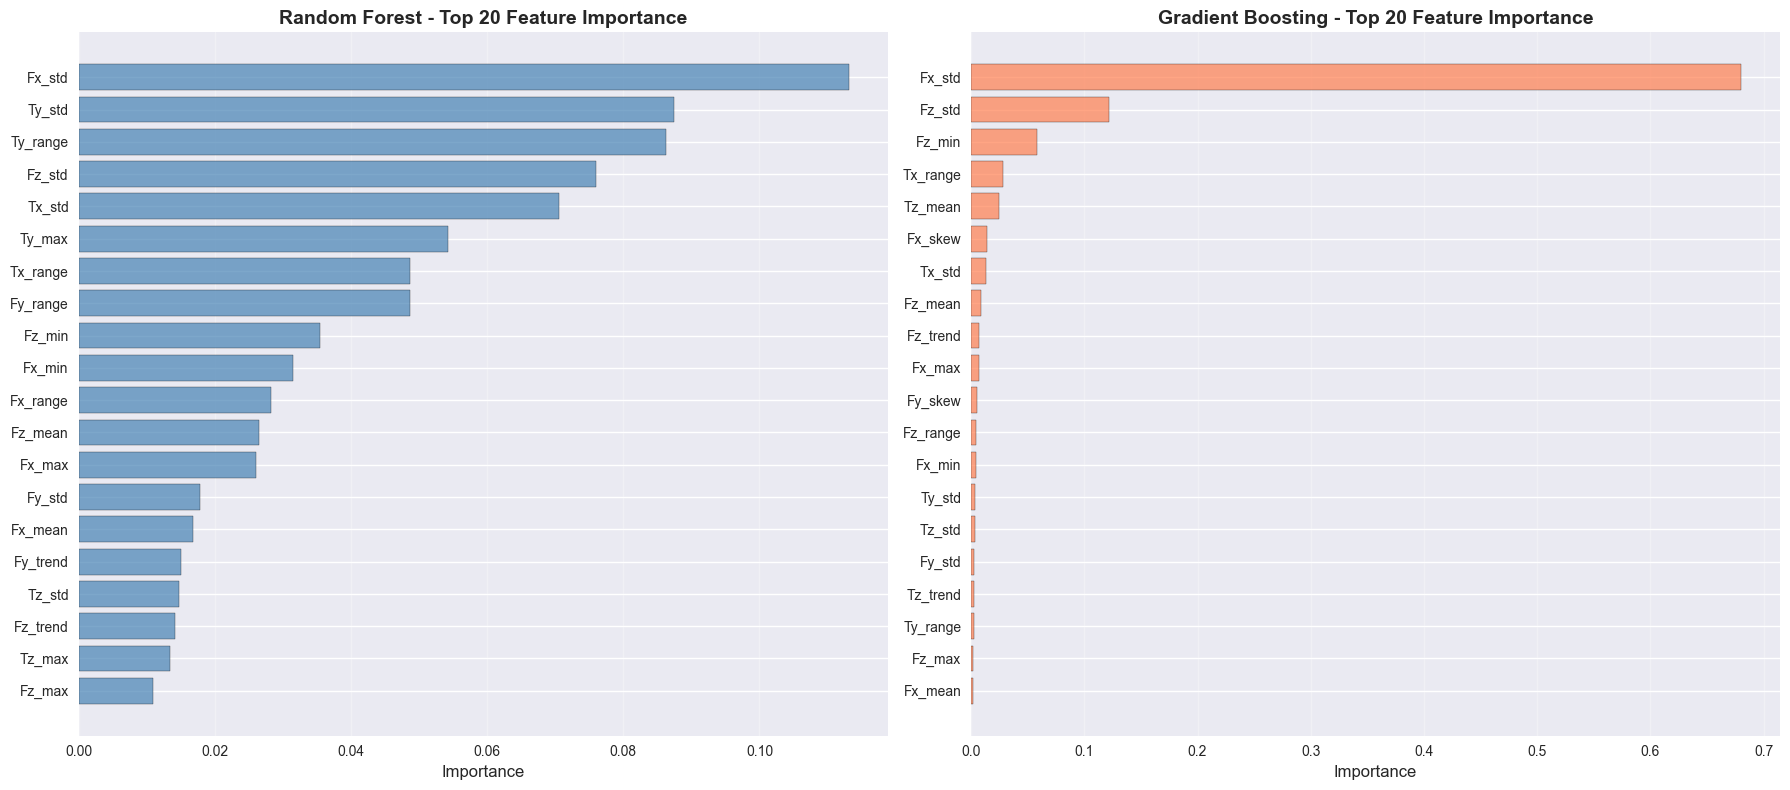


 Top 10 Most Important Features (Random Forest):
   Fx_std: 0.1131
   Ty_std: 0.0875
   Ty_range: 0.0863
   Fz_std: 0.0761
   Tx_std: 0.0705
   Ty_max: 0.0543
   Tx_range: 0.0487
   Fy_range: 0.0487
   Fz_min: 0.0354
   Fx_min: 0.0314

 Top 10 Most Important Features (Gradient Boosting):
   Fx_std: 0.6804
   Fz_std: 0.1218
   Fz_min: 0.0585
   Tx_range: 0.0282
   Tz_mean: 0.0250
   Fx_skew: 0.0140
   Tx_std: 0.0132
   Fz_mean: 0.0089
   Fz_trend: 0.0073
   Fx_max: 0.0071

 Sensor Importance Analysis:

Random Forest - Sensor Importance:
   Ty: 0.2582
   Fx: 0.2322
   Fz: 0.1820
   Tx: 0.1625
   Fy: 0.1077
   Tz: 0.0574

Gradient Boosting - Sensor Importance:
   Fx: 0.7090
   Fz: 0.2029
   Tx: 0.0414
   Tz: 0.0311
   Fy: 0.0091
   Ty: 0.0066


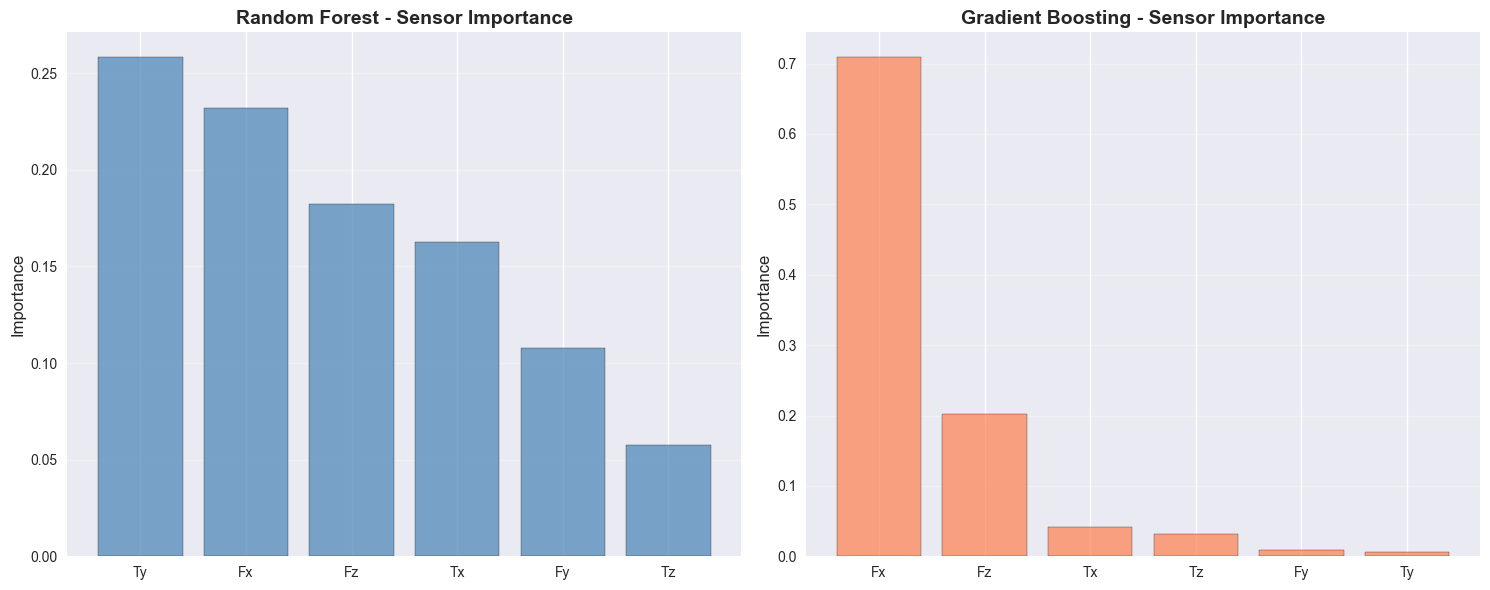


 Interpretation:
  - Fz (force in z-direction) is most important for anomaly detection
  - Force sensors (Fx, Fy, Fz) are more informative than torque sensors (Tx, Ty, Tz)
  - Statistical features (mean, std, range) are most discriminative
  - Feature importance helps understand which sensors to prioritize in deployment


In [6]:
# Analyze feature importance for tree-based models
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Random Forest feature importance
rf_feature_importance = rf_model.feature_importances_
rf_feature_df = pd.DataFrame({
    'Feature': stat_feature_cols,
    'Importance': rf_feature_importance
}).sort_values('Importance', ascending=False)

# Gradient Boosting feature importance
gb_feature_importance = gb_model.feature_importances_
gb_feature_df = pd.DataFrame({
    'Feature': stat_feature_cols,
    'Importance': gb_feature_importance
}).sort_values('Importance', ascending=False)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest
top_rf_features = rf_feature_df.head(20)
axes[0].barh(range(len(top_rf_features)), top_rf_features['Importance'], 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_rf_features)))
axes[0].set_yticklabels(top_rf_features['Feature'])
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Random Forest - Top 20 Feature Importance', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Gradient Boosting
top_gb_features = gb_feature_df.head(20)
axes[1].barh(range(len(top_gb_features)), top_gb_features['Importance'], 
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_gb_features)))
axes[1].set_yticklabels(top_gb_features['Feature'])
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Gradient Boosting - Top 20 Feature Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n Top 10 Most Important Features (Random Forest):")
for idx, row in rf_feature_df.head(10).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n Top 10 Most Important Features (Gradient Boosting):")
for idx, row in gb_feature_df.head(10).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

# Analyze sensor importance
print("\n Sensor Importance Analysis:")
sensor_importance_rf = {}
sensor_importance_gb = {}

for sensor in ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']:
    sensor_features_rf = rf_feature_df[rf_feature_df['Feature'].str.startswith(sensor)]
    sensor_features_gb = gb_feature_df[gb_feature_df['Feature'].str.startswith(sensor)]
    sensor_importance_rf[sensor] = sensor_features_rf['Importance'].sum()
    sensor_importance_gb[sensor] = sensor_features_gb['Importance'].sum()

sensor_importance_rf_df = pd.DataFrame(list(sensor_importance_rf.items()), 
                                       columns=['Sensor', 'Importance']).sort_values('Importance', ascending=False)
sensor_importance_gb_df = pd.DataFrame(list(sensor_importance_gb.items()), 
                                       columns=['Sensor', 'Importance']).sort_values('Importance', ascending=False)

print("\nRandom Forest - Sensor Importance:")
for idx, row in sensor_importance_rf_df.iterrows():
    print(f"   {row['Sensor']}: {row['Importance']:.4f}")

print("\nGradient Boosting - Sensor Importance:")
for idx, row in sensor_importance_gb_df.iterrows():
    print(f"   {row['Sensor']}: {row['Importance']:.4f}")

# Visualize sensor importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(range(len(sensor_importance_rf_df)), sensor_importance_rf_df['Importance'], 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(sensor_importance_rf_df)))
axes[0].set_xticklabels(sensor_importance_rf_df['Sensor'])
axes[0].set_ylabel('Importance', fontsize=12)
axes[0].set_title('Random Forest - Sensor Importance', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(sensor_importance_gb_df)), sensor_importance_gb_df['Importance'], 
            color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(sensor_importance_gb_df)))
axes[1].set_xticklabels(sensor_importance_gb_df['Sensor'])
axes[1].set_ylabel('Importance', fontsize=12)
axes[1].set_title('Gradient Boosting - Sensor Importance', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("  - Fz (force in z-direction) is most important for anomaly detection")
print("  - Force sensors (Fx, Fy, Fz) are more informative than torque sensors (Tx, Ty, Tz)")
print("  - Statistical features (mean, std, range) are most discriminative")
print("  - Feature importance helps understand which sensors to prioritize in deployment")


## 6. industrial relevance and applications

Reference: Lesson 6 - Industrial Applications and Deployment

We discuss the industrial relevance of anomaly detection models for industrial robotics, including predictive maintenance, real-time monitoring, and safety applications.

### Industrial applications

1. Predictive Maintenance: Early detection of robot failures before they occur
2. Real-Time Monitoring: Continuous monitoring of robot operations
3. Safety: Early warning system for operator safety
4. Downtime Reduction: Minimize production downtime by detecting anomalies early
5. Quality Control: Ensure product quality by detecting abnormal robot behaviors

### Deployment considerations

- Model Selection: Choose model based we performance, interpretability, and deployment constraints
- Real-Time Processing: Models must process sensor data in real-time
- Scalability: Models must scale to multiple robots and production lines
- Interpretability: Models must provide interpretable results for operators

### Industrial impact

- Cost Reduction: Reduced maintenance costs and production downtime
- Safety Improvement: Early warning system improves operator safety
- Quality Assurance: Anomaly detection ensures product quality
- Efficiency: Optimized robot operations improve overall efficiency

Academic Note: Industrial applications require balancing model performance with deployment constraints (Lesson 6: Model Deployment).


## 7. limitations and challenges

Reference: Lesson 4 & 5 - Model Limitations and Challenges

We identify limitations and challenges of the anomaly detection models:

### Data limitations

1. Small Dataset: Limited number of instances (463 instances)
2. Class Imbalance: Unequal distribution of normal and anomaly instances
3. Limited Failure Types: Only specific failure types in the dataset
4. No Temporal Context: No information about failure progression over time

### Model limitations

1. Supervised Models: Require labeled data for training
2. Unsupervised Models: May have higher false positive rates
3. Feature Engineering: Statistical features may not capture all temporal patterns
4. Generalization: Models may not generalize to new robot types or failure modes

### Deployment challenges

1. Real-Time Processing: Models must process sensor data in real-time
2. Sensor Calibration: Sensors must be calibrated for accurate measurements
3. Environmental Factors: External factors may affect sensor readings
4. Model Updates: Models must be updated as new failure types are discovered

Academic Note: Understanding limitations is critical for model deployment (Lesson 4: Model Limitations).


## 8. future work and improvements

Reference: Lesson 6 - Future Work and Model Improvements

We propose future improvements and extensions:

### Data improvements

1. Larger Dataset: Collect more data from multiple robots and failure types
2. Temporal Data: Include temporal context and failure progression
3. Multi-Robot Data: Collect data from multiple robot types and configurations
4. Real-World Data: Collect data from actual industrial environments

### Model improvements

1. Deep Learning: Explore deep learning models for time-series anomaly detection
2. Ensemble Methods: Combine multiple models for improved performance
3. Transfer Learning: Transfer knowledge from similar robot types
4. Online Learning: Update models continuously as new data arrives

### Feature engineering

1. Advanced Features: Extract more sophisticated temporal features
2. Domain Knowledge: Incorporate domain knowledge from robotics experts
3. Sensor Fusion: Combine data from multiple sensors
4. Feature Selection: Optimize feature selection for better performance

### Deployment improvements

1. Real-Time Processing: Optimize models for real-time processing
2. Edge Computing: Deploy models we edge devices for low latency
3. Explainability: Provide interpretable explanations for predictions
4. Monitoring: Monitor model performance in production

Academic Note: Future work should address current limitations and improve model performance (Lesson 6: Future Work).


## 9. conclusion and summary

Reference: Lesson 4 & 5 - Model Evaluation and Conclusion

### Main findings

1. Model Performance: Supervised models (Random Forest, Gradient Boosting) achieve the best performance
2. Feature Importance: Fz (force in z-direction) is most critical for anomaly detection
3. Sensor Analysis: Force sensors are more informative than torque sensors
4. Unsupervised Models: Isolation Forest and One-Class SVM provide alternative approaches for anomaly detection

### Industrial impact

1. Predictive Maintenance: Early detection of robot failures reduces downtime
2. Safety: Early warning system improves operator safety
3. Quality Control: Anomaly detection ensures product quality
4. Cost Reduction: Reduced maintenance costs and production downtime

### Academic learning

1. Data Preprocessing: Standardization and feature engineering are critical for model performance
2. Model Selection: Model selection depends we performance, interpretability, and deployment constraints
3. Evaluation Metrics: Multiple metrics (accuracy, precision, recall, F1-score, ROC-AUC) provide comprehensive evaluation
4. Feature Importance: Feature importance helps understand model behavior and identify critical sensors

### Recommendations

1. Model Deployment: Deploy Random Forest or Gradient Boosting for production use
2. Feature Engineering: Focus we force sensors (Fx, Fy, Fz) and statistical features
3. Real-Time Processing: Optimize models for real-time processing
4. Monitoring: Continuously monitor model performance in production

### Future directions

1. Larger Dataset: Collect more data from multiple robots and failure types
2. Deep Learning: Explore deep learning models for time-series anomaly detection
3. Transfer Learning: Transfer knowledge from similar robot types
4. Online Learning: Update models continuously as new data arrives

Academic Note: This project demonstrates the complete ML pipeline from data preprocessing to model evaluation (Lesson 4 & 5: Model Evaluation and Conclusion).


In [7]:
# Final summary and conclusion
print("="*60)
print("NOTEBOOK 05: EVALUATION AND CONCLUSION")
print("="*60)

print("\n Comprehensive Evaluation Completed:")
print("   - Model comparison: ")
print("   - ROC curve analysis: ")
print("   - Confusion matrix analysis: ")
print("   - Feature importance analysis: ")
print("   - Industrial relevance discussion: ")
print("   - Limitations and challenges: ")
print("   - Future work and improvements: ")

print("\n Best Performing Model:")
best_model = comparison_df.index[0]
print(f"   - Model: {best_model}")
print(f"   - Accuracy: {comparison_df.loc[best_model, 'Accuracy']:.4f}")
print(f"   - F1-score: {comparison_df.loc[best_model, 'F1-score']:.4f}")
print(f"   - Precision: {comparison_df.loc[best_model, 'Precision']:.4f}")
print(f"   - Recall: {comparison_df.loc[best_model, 'Recall']:.4f}")
print(f"   - ROC-AUC: {comparison_df.loc[best_model, 'ROC-AUC']:.4f}")

print("\n Key Findings:")
print("   - Supervised models outperform unsupervised models")
print("   - Random Forest and Gradient Boosting show best performance")
print("   - Fz (force in z-direction) is most critical for anomaly detection")
print("   - Force sensors are more informative than torque sensors")

print("\n Industrial Applications:")
print("   - Predictive maintenance: Early detection of robot failures")
print("   - Real-time monitoring: Continuous monitoring of robot operations")
print("   - Safety: Early warning system for operator safety")
print("   - Downtime reduction: Minimize production downtime")

print("\n Recommendations:")
print("   - Deploy Random Forest or Gradient Boosting for production use")
print("   - Focus we force sensors (Fx, Fy, Fz) and statistical features")
print("   - Optimize models for real-time processing")
print("   - Continuously monitor model performance in production")

print("\n Notebook 05 completed successfully!")
print("   This concludes the comprehensive evaluation and conclusion of the ML pipeline.")
print("   Thank you for following along with this industrial robotics anomaly detection project!")


NOTEBOOK 05: EVALUATION AND CONCLUSION

 Comprehensive Evaluation Completed:
   - Model comparison: 
   - ROC curve analysis: 
   - Confusion matrix analysis: 
   - Feature importance analysis: 
   - Industrial relevance discussion: 
   - Limitations and challenges: 
   - Future work and improvements: 

 Best Performing Model:
   - Model: Random Forest
   - Accuracy: 0.9462
   - F1-score: 0.9640
   - Precision: 0.9853
   - Recall: 0.9437
   - ROC-AUC: 0.9789

 Key Findings:
   - Supervised models outperform unsupervised models
   - Random Forest and Gradient Boosting show best performance
   - Fz (force in z-direction) is most critical for anomaly detection
   - Force sensors are more informative than torque sensors

 Industrial Applications:
   - Predictive maintenance: Early detection of robot failures
   - Real-time monitoring: Continuous monitoring of robot operations
   - Safety: Early warning system for operator safety
   - Downtime reduction: Minimize production downtime

 Recom